This notebook will be used to prepare the data for the project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
df = pd.read_csv('dataset/train.csv')

print(df.head())
print(df.info())
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [4]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
#mean/median imputation for Age missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
# Unknown for Cabin
df['Cabin'] = df['Cabin'].fillna('Unknown')

# print(df.Embarked.value_counts())
# Fill 'Embarked' with the most common value
df.Embarked = df.Embarked.fillna('S')

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [6]:
df_test = pd.read_csv('dataset/test.csv')

print(df_test.head())
print(df_test.info())
print(df_test.describe())
print(df_test.isnull().sum())


   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ------------

In [7]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())
df_test['Cabin'] = df_test['Cabin'].fillna('Unknown')

print(df_test.isnull().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [8]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)



In [9]:
print(df.head())
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare    Cabin  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500  Unknown       False        True  
1          PC 17599  71.2833      C85       False       False  
2  STON/O2. 3101282   7.9250  Unknown       False        True  
3            113803  53.1000     C123   

In [10]:
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

df_test = pd.get_dummies(df_test, columns=['Embarked'], drop_first=True)


print(df_test.head())
print(df_test.info())

   PassengerId  Pclass                                          Name  Sex  \
0          892       3                              Kelly, Mr. James    0   
1          893       3              Wilkes, Mrs. James (Ellen Needs)    1   
2          894       2                     Myles, Mr. Thomas Francis    0   
3          895       3                              Wirz, Mr. Albert    0   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1   

    Age  SibSp  Parch   Ticket     Fare    Cabin  Embarked_Q  Embarked_S  
0  34.5      0      0   330911   7.8292  Unknown        True       False  
1  47.0      1      0   363272   7.0000  Unknown       False        True  
2  62.0      0      0   240276   9.6875  Unknown        True       False  
3  27.0      0      0   315154   8.6625  Unknown       False        True  
4  22.0      1      1  3101298  12.2875  Unknown       False        True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (t

Feature Engineering

In [11]:
df['Deck'] = df['Cabin'].str[0]
df_test['Deck'] = df_test['Cabin'].str[0]

df = pd.get_dummies(df, columns=['Deck'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Deck'], drop_first=True)



In [12]:
#print(df.Name.unique())

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print(df.Title.unique())
print(df_test.Title.unique())

df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona','Sir'], 'Rare')
df_test['Title'] = df_test['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')

df['Title'] = df['Title'].replace('Mlle', 'Miss')
df_test['Title'] = df_test['Title'].replace('Mlle', 'Miss')

df['Title'] = df['Title'].replace('Ms', 'Miss')
df_test['Title'] = df_test['Title'].replace('Ms', 'Miss')

df['Title'] = df['Title'].replace('Mme', 'Mrs')
df_test['Title'] = df_test['Title'].replace('Mme', 'Mrs')

print(df.Title.unique())
print(df_test.Title.unique())

title_map = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
df['Title'] = df['Title'].map(title_map)
df_test['Title'] = df_test['Title'].map(title_map)

print(df.Title.unique())
print(df_test.Title.unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
['Mr' 'Mrs' 'Miss' 'Master' 'Ms' 'Col' 'Rev' 'Dr' 'Dona']
['Mr' 'Mrs' 'Miss' 'Master' 'Rare']
['Mr' 'Mrs' 'Miss' 'Master' 'Rare']
[1 3 2 4 5]
[1 3 2 4 5]


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\longo\AppData\Local\Temp\ipykernel_1188\3304456854.py:3: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\longo\AppData\Local\Temp\ipykernel_1188\3304456854.py:4: SyntaxWarning: invalid escape sequence '\.'
  df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Feature Selection

In [13]:
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
df_test = df_test.drop(['Name', 'Ticket', 'Cabin'], axis=1)



In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked_Q   891 non-null    bool   
 9   Embarked_S   891 non-null    bool   
 10  Deck_B       891 non-null    bool   
 11  Deck_C       891 non-null    bool   
 12  Deck_D       891 non-null    bool   
 13  Deck_E       891 non-null    bool   
 14  Deck_F       891 non-null    bool   
 15  Deck_G       891 non-null    bool   
 16  Deck_T       891 non-null    bool   
 17  Deck_U       891 non-null    bool   
 18  Title        891 non-null    int64  
dtypes: bool(

Normalization

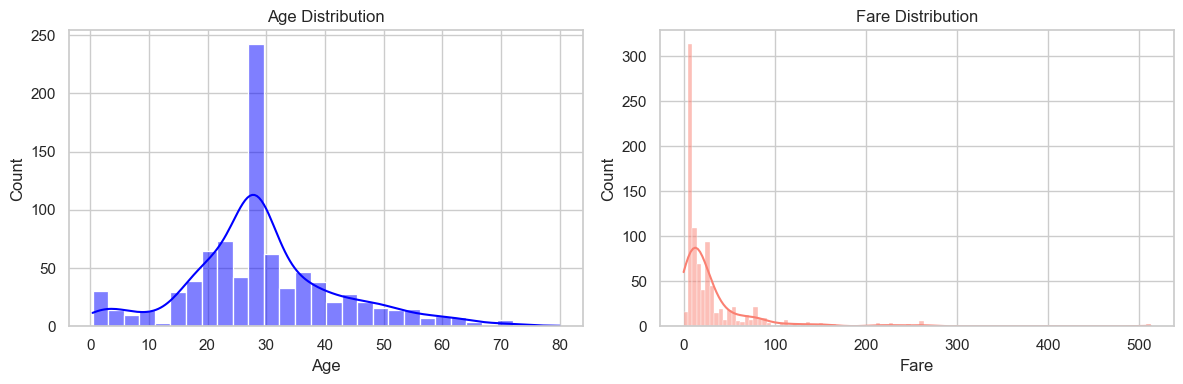

In [15]:
sns.set(style="whitegrid")

#Age Distribution

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Age Distribution')


#Fare Distribution

plt.subplot(1, 2, 2)
sns.histplot(df['Fare'], kde=True, color='salmon')
plt.title('Fare Distribution')

plt.tight_layout()
plt.show()

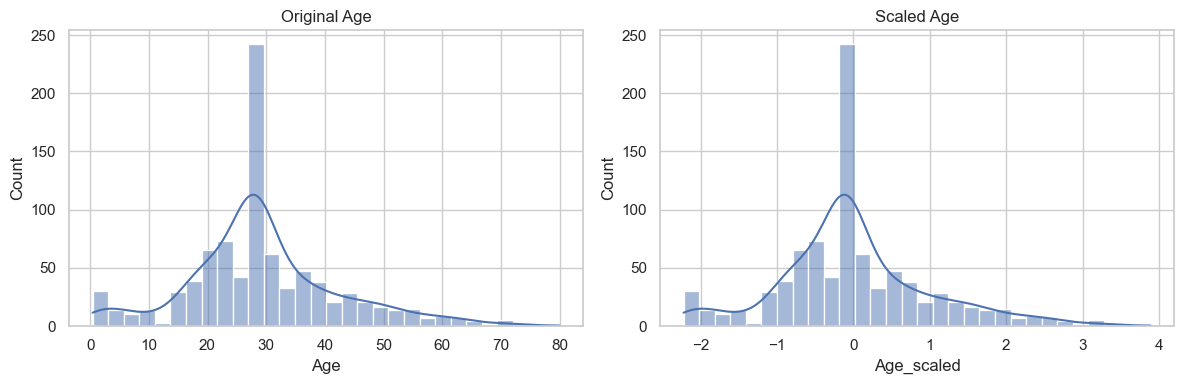

In [16]:
df['Age_scaled'] = StandardScaler().fit_transform(df['Age'].values.reshape(-1, 1))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Age'], kde=True, ax=ax[0])
ax[0].set_title('Original Age')
sns.histplot(df['Age_scaled'], kde=True, ax=ax[1])
ax[1].set_title('Scaled Age')
plt.tight_layout()
plt.show()

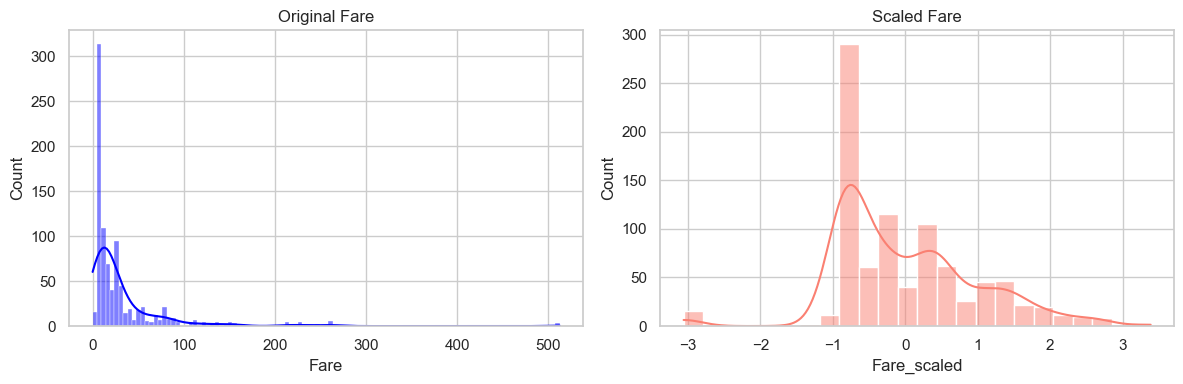

In [17]:
df['Fare_scaled'] = StandardScaler().fit_transform(np.log1p(df['Fare'].values.reshape(-1, 1)))

plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True, color='blue')
plt.title('Original Fare')

plt.subplot(1,2,2)
sns.histplot(df['Fare_scaled'], kde=True, color='salmon')
plt.title('Scaled Fare')

plt.tight_layout()
plt.show()

In [18]:
# For test data

df_test['Age_scaled'] = StandardScaler().fit_transform(df_test['Age'].values.reshape(-1, 1))
df_test['Fare_scaled'] = StandardScaler().fit_transform(np.log1p(df_test['Fare'].values.reshape(-1, 1)))



In [ ]:
df_test.head()


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_U,Title,Age_scaled,Fare_scaled
0,892,3,0,34.5,0,0,7.8292,True,False,False,False,False,False,False,False,True,1,0.386231,-0.867031
1,893,3,1,47.0,1,0,7.0000,False,True,False,False,False,False,False,False,True,3,1.371370,-0.969149
2,894,2,0,62.0,0,0,9.6875,True,False,False,False,False,False,False,False,True,1,2.553537,-0.669252
3,895,3,0,27.0,0,0,8.6625,False,True,False,False,False,False,False,False,True,1,-0.204852,-0.773647
4,896,3,1,22.0,1,1,12.2875,False,True,False,False,False,False,False,False,True,3,-0.598908,-0.443786


In [21]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,...,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Title,Age_scaled,Fare_scaled
0,1,0,3,0,22.0,1,0,7.2500,False,True,...,False,False,False,False,False,False,True,1,-0.565736,-0.879741
1,2,1,1,1,38.0,1,0,71.2833,False,False,...,True,False,False,False,False,False,False,3,0.663861,1.361220
2,3,1,3,1,26.0,0,0,7.9250,False,True,...,False,False,False,False,False,False,True,2,-0.258337,-0.798540
3,4,1,1,1,35.0,1,0,53.1000,False,True,...,True,False,False,False,False,False,False,3,0.433312,1.062038
4,5,0,3,0,35.0,0,0,8.0500,False,True,...,False,False,False,False,False,False,True,1,0.433312,-0.784179


In [24]:
df_test['Deck_T'] = False


In [25]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_U,Title,Age_scaled,Fare_scaled,Deck_T
0,892,3,0,34.5,0,0,7.8292,True,False,False,False,False,False,False,False,True,1,0.386231,-0.867031,False
1,893,3,1,47.0,1,0,7.0000,False,True,False,False,False,False,False,False,True,3,1.371370,-0.969149,False
2,894,2,0,62.0,0,0,9.6875,True,False,False,False,False,False,False,False,True,1,2.553537,-0.669252,False
3,895,3,0,27.0,0,0,8.6625,False,True,False,False,False,False,False,False,True,1,-0.204852,-0.773647,False
4,896,3,1,22.0,1,1,12.2875,False,True,False,False,False,False,False,False,True,3,-0.598908,-0.443786,False


In [ ]:
df.to_csv('dataset/train_cleaned.csv', index=False)

df_test.to_csv('dataset/test_cleaned.csv', index=False)